<a href="https://colab.research.google.com/github/PawaniMekhala/AI-Driven-Student-Dropout-Prediction/blob/main/05_ensemble_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier


PROJECT_ROOT = "/content/drive/MyDrive/student-dropout-prediction"

X_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_train.csv")
y_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_train.csv").values.ravel()

X_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_test.csv")
y_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_test.csv").values.ravel()


Mounted at /content/drive


In [ ]:
# Logistic Regression pipeline (scaled)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=42
    ))
])

# Random Forest (no scaling)
rf_pipeline = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# XGBoost (no scaling)
xgb_pipeline = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    gamma=0.5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='logloss'
)


In [ ]:
# VOTING ENSEMBLE - use Soft Voting
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_pipeline),
        ('rf', rf_pipeline),
        ('xgb', xgb_pipeline)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)


VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('lr',
                                               LogisticRegression(class_weight='balanced',
                                                                  max_iter=5000,
                                                                  random_state=42))])),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=15,
                                                     min_samples_split=10,
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callb...
                                            feature_weights=None, gamma=0.5,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=10, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [ ]:
# Evaluate Ensemble
y_pred_ensemble = voting_clf.predict(X_test)

print(classification_report(y_test, y_pred_ensemble))


              precision    recall  f1-score   support

           0       0.90      0.89      0.89       601
           1       0.77      0.80      0.78       284

    accuracy                           0.86       885
   macro avg       0.83      0.84      0.84       885
weighted avg       0.86      0.86      0.86       885



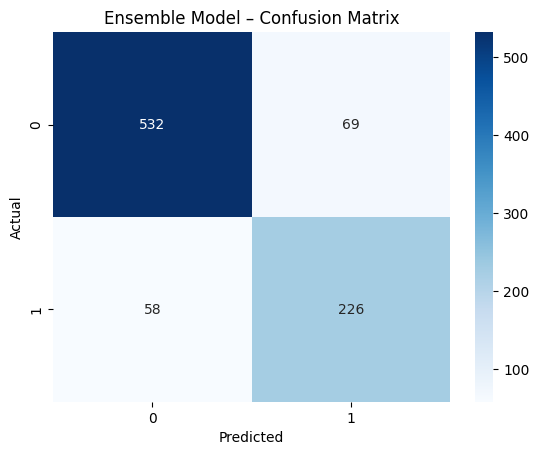

In [ ]:
# Confusion Matrix
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)

sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Ensemble Model – Confusion Matrix")
plt.show()


In [ ]:
tn, fp, fn, tp = cm_ensemble.ravel()

print(f"""
Ensemble Model Confusion Matrix:
--------------------------------
            Predicted
            0     1
Actual 0   {tn}    {fp}
Actual 1   {fn}    {tp}
""")


Ensemble Model Confusion Matrix:
--------------------------------
            Predicted
            0     1
Actual 0   532    69
Actual 1   58    226



In [ ]:
# Save Ensemble Metrics
ensemble_results = pd.DataFrame({
    "Model": ["Ensemble (Voting)"],
    "Accuracy": [accuracy_score(y_test, y_pred_ensemble)],
    "Precision": [precision_score(y_test, y_pred_ensemble)],
    "Recall": [recall_score(y_test, y_pred_ensemble)],
    "F1-score": [f1_score(y_test, y_pred_ensemble)]
})

ensemble_results.to_csv(
    f"{PROJECT_ROOT}/results/metrics/ensemble_results.csv",
    index=False
)

ensemble_results


,Model,Accuracy,Precision,Recall,F1-score
0,Ensemble (Voting),0.856497,0.766102,0.795775,0.780656


In [ ]:
# Load saved metric files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = "/content/drive/MyDrive/student-dropout-prediction"

lr = pd.read_csv(f"{PROJECT_ROOT}/results/metrics/logistic_regression_results.csv")
dt = pd.read_csv(f"{PROJECT_ROOT}/results/metrics/decision_tree_results.csv")
rf = pd.read_csv(f"{PROJECT_ROOT}/results/metrics/random_forest_results.csv")
xgb = pd.read_csv(f"{PROJECT_ROOT}/results/metrics/xgboost_results.csv")
ens = pd.read_csv(f"{PROJECT_ROOT}/results/metrics/ensemble_results.csv")


In [ ]:
# Combine into one DataFrame
results = pd.concat([lr, dt, rf, xgb, ens], ignore_index=True)
results


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.841808,0.730769,0.802817,0.765101
1,Decision Tree,0.827119,0.700306,0.806338,0.749591
2,Random Forest,0.858757,0.804598,0.739437,0.770642
3,XGBoost,0.849718,0.742765,0.813380,0.776471
4,Ensemble (Voting),0.856497,0.766102,0.795775,0.780656


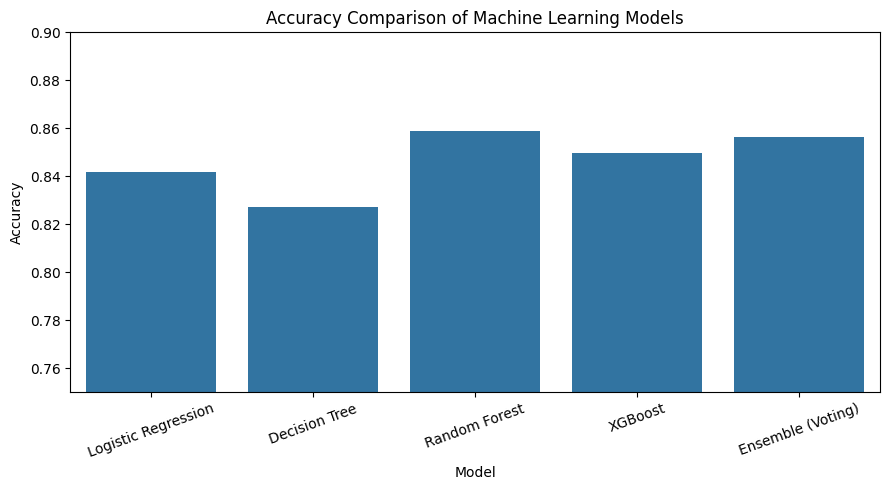

In [ ]:
# Accuracy comparison
plt.figure(figsize=(9,5))
sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0.75, 0.9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


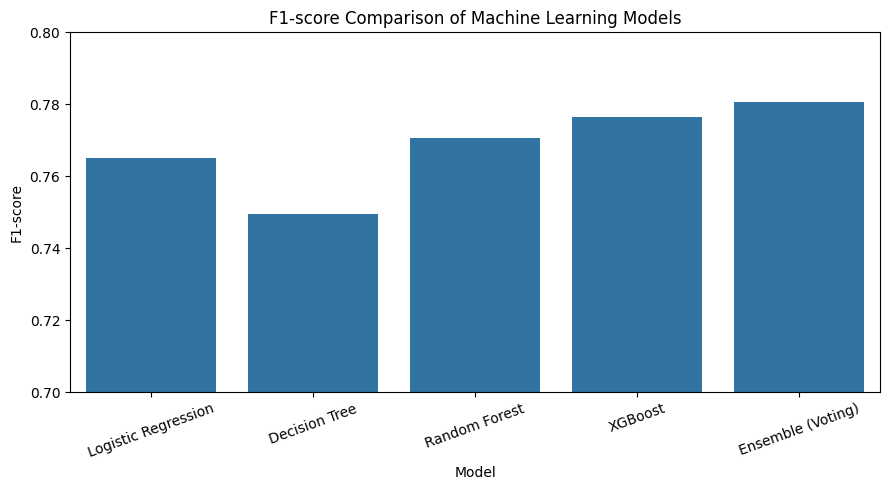

In [ ]:
# F1-score comparison
plt.figure(figsize=(9,5))
sns.barplot(
    x="Model",
    y="F1-score",
    data=results
)

plt.title("F1-score Comparison of Machine Learning Models")
plt.ylabel("F1-score")
plt.xlabel("Model")
plt.ylim(0.7, 0.8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
